In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset
df = pd.read_csv('wesad_6features_balanced.csv')
features = ['bvp_mean', 'bvp_std', 'temp_mean', 'temp_std', 'acc_mag_mean', 'acc_mag_std']
print(f"Shape: {df.shape}")
df.head()

Shape: (4500, 7)


,bvp_mean,bvp_std,temp_mean,temp_std,acc_mag_mean,acc_mag_std,emotion
0,-0.2290,12.8382,31.126,0.0080,62.6925,3.7878,Bhayanaka
1,0.0186,5.1897,30.211,0.0118,63.0637,0.0031,Hasya
2,8.3005,83.0514,32.624,0.0156,63.4865,9.4520,Bhayanaka
3,1.4813,77.9063,33.810,0.0155,64.0958,11.6544,Bhayanaka
4,0.0782,3.4951,31.558,0.0098,65.1498,0.1738,Shanta


In [3]:
# Data Info & Missing Values 
print(df.info())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nClass Distribution:\n{df['emotion'].value_counts()}")

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bvp_mean      4500 non-null   float64
 1   bvp_std       4500 non-null   float64
 2   temp_mean     4500 non-null   float64
 3   temp_std      4500 non-null   float64
 4   acc_mag_mean  4500 non-null   float64
 5   acc_mag_std   4500 non-null   float64
 6   emotion       4500 non-null   str    
dtypes: float64(6), str(1)
memory usage: 246.2 KB
None

Missing values: 0
Duplicates: 0

Class Distribution:
emotion
Bhayanaka    1500
Hasya        1500
Shanta       1500
Name: count, dtype: int64


In [4]:
# Descriptive Statistics 
df.describe().round(4)

,bvp_mean,bvp_std,temp_mean,temp_std,acc_mag_mean,acc_mag_std
count,4500.0000,4500.0000,4500.0000,4500.0000,4500.0000,4500.0000
mean,0.0149,31.8970,32.6779,0.0115,63.5885,1.7175
std,1.6807,36.7756,1.4322,0.0050,0.9987,3.2255
min,-26.7027,0.8715,29.0450,0.0000,62.0476,0.0000
25%,-0.3803,9.8962,31.7580,0.0089,62.8793,0.2887
50%,-0.0300,19.0828,32.8300,0.0100,63.1768,0.4572
75%,0.3670,38.6238,33.6640,0.0150,64.3172,1.2334
max,17.9023,411.3461,35.9540,0.0483,71.4367,25.6654


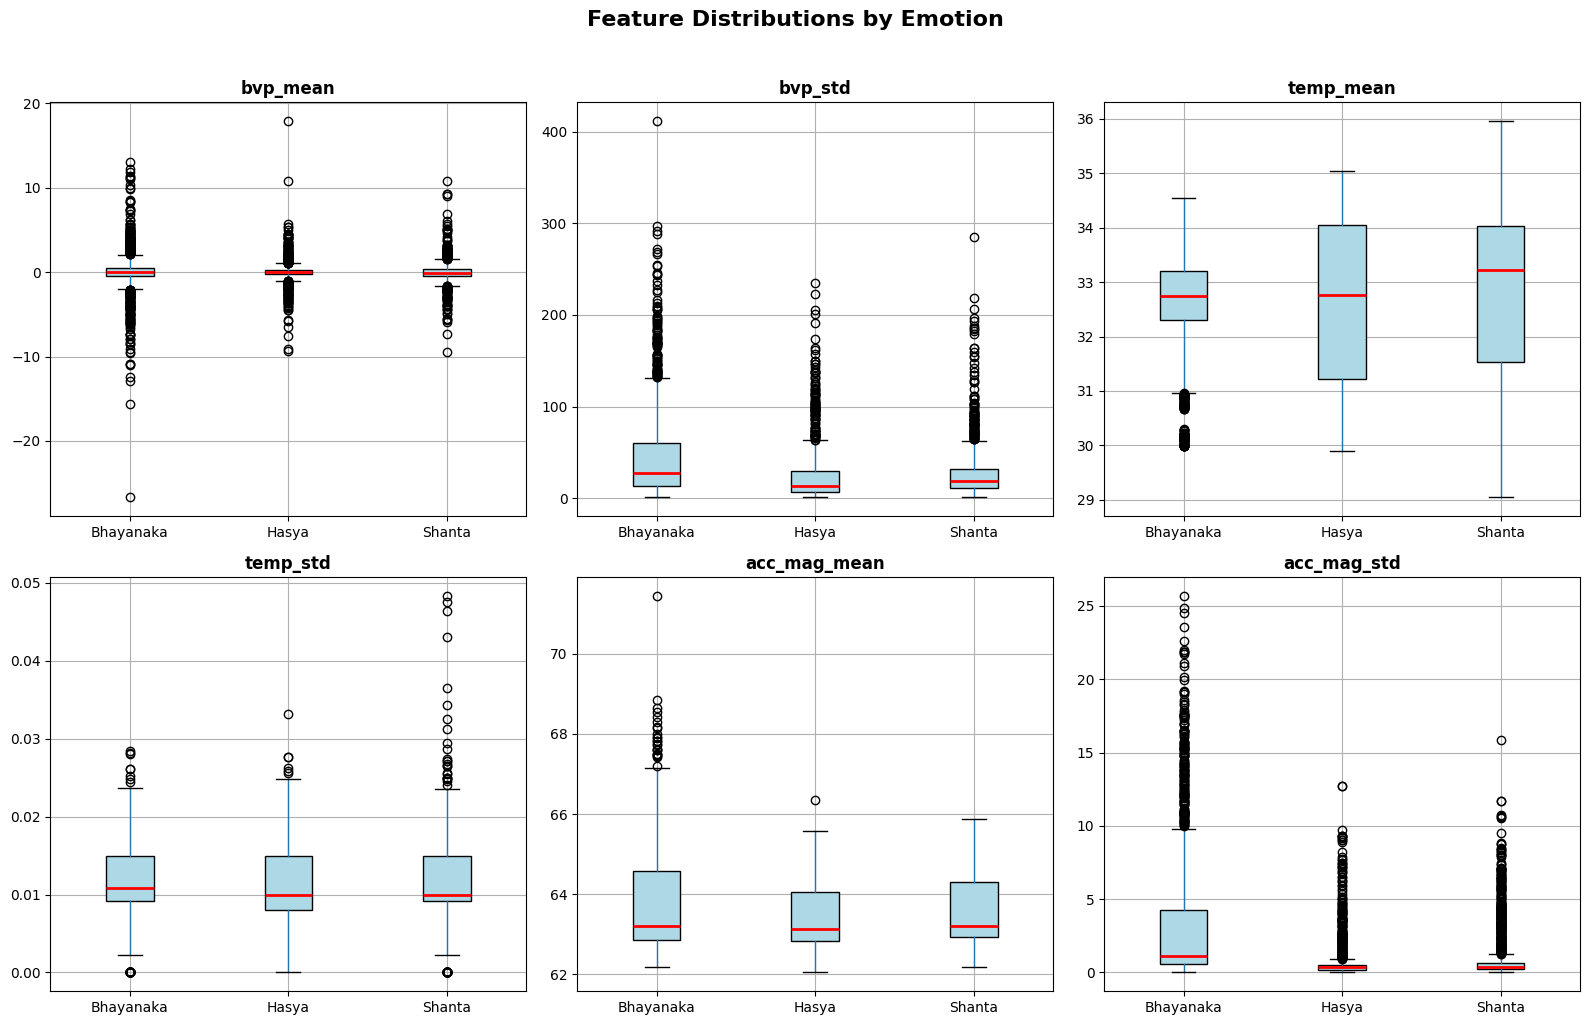

In [5]:
# Boxplots by Emotion 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, feat in enumerate(features):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=feat, by='emotion', ax=ax, patch_artist=True,
               boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
fig.suptitle('Feature Distributions by Emotion', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

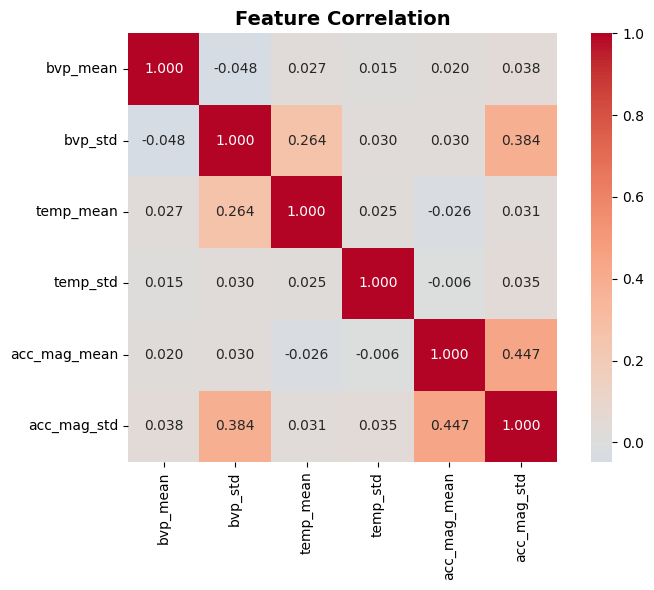

In [6]:
# Correlation Heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Encode Labels & Train-Test Split 
le = LabelEncoder()
y = le.fit_transform(df['emotion'])
X = df[features].values

print(f"Label Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Label Mapping: {'Bhayanaka': 0, 'Hasya': 1, 'Shanta': 2}
Training samples: 3600
Test samples:     900


In [8]:
# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Scaled std:  {X_train_scaled.std(axis=0).round(4)}")

Scaled mean: [-0.  0.  0.  0. -0. -0.]
Scaled std:  [1. 1. 1. 1. 1. 1.]


In [9]:
# Train & Compare Models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name:<22} CV: {cv_scores.mean():.4f}  Test: {test_acc:.4f}")

Logistic Regression    CV: 0.4794  Test: 0.4922
KNN                    CV: 0.6856  Test: 0.7267
SVM                    CV: 0.6164  Test: 0.6544
Random Forest          CV: 0.8600  Test: 0.8844
Gradient Boosting      CV: 0.8403  Test: 0.8722
MLP                    CV: 0.7758  Test: 0.8156


              precision    recall  f1-score   support

   Bhayanaka       0.89      0.90      0.89       300
       Hasya       0.91      0.89      0.90       300
      Shanta       0.86      0.86      0.86       300

    accuracy                           0.88       900
   macro avg       0.88      0.88      0.88       900
weighted avg       0.88      0.88      0.88       900



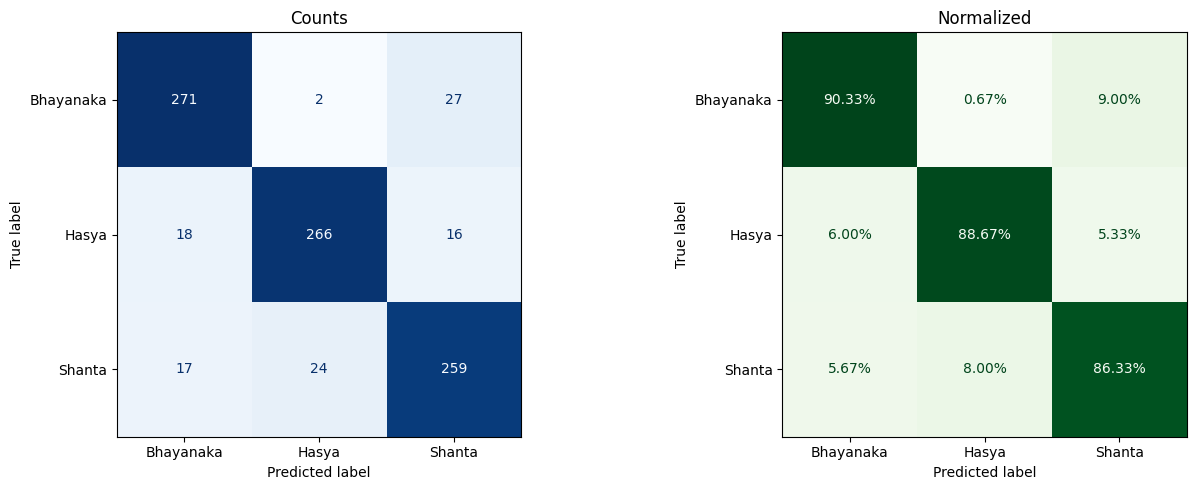


PER-CLASS ACCURACY:
  Bhayanaka: 0.9033 (271/300)
  Hasya: 0.8867 (266/300)
  Shanta: 0.8633 (259/300)


In [10]:
# Evaluate Best Model 
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize='true'), display_labels=le.classes_).plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.2%')
axes[1].set_title('Normalized')
plt.tight_layout()
plt.show()

# Per-class accuracy
print('\nPER-CLASS ACCURACY:')
for i, cls in enumerate(le.classes_):
    mask = y_test == i
    cls_acc = accuracy_score(y_test[mask], y_pred[mask])
    print(f'  {cls}: {cls_acc:.4f} ({(y_test[mask] == y_pred[mask]).sum()}/{mask.sum()})')

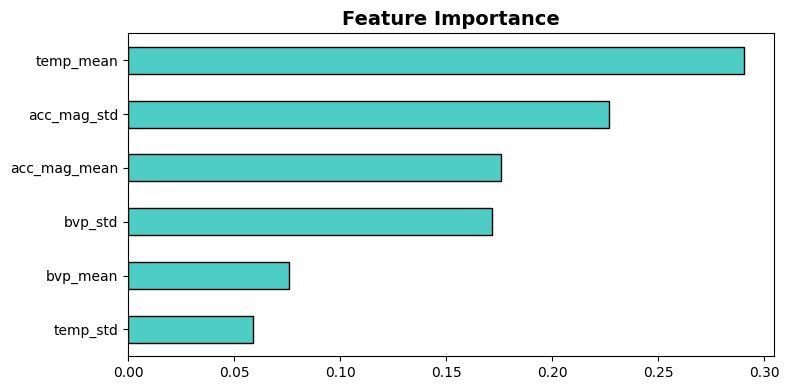

In [11]:
# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='#4ECDC4', edgecolor='black', figsize=(8, 4))
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()